#LAB 5
NEURAL NETWORKS AND DEEP LEARNING||
LAB TUTORIAL||
Learning compact representations through reconstruction
##Autoencoders using PyTorch

## Step 1: Import libraries and select device

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


## Step 2: Load and normalize MNIST

In [12]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)
print("Training samples:", len(train_data))
print("Test samples:", len(test_data))

Training samples: 60000
Test samples: 10000


## Step 3: Define the autoencoder

In [15]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z # Return both reconstructed image and latent representation

model = Autoencoder(latent_dim=32).to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


## Step 4: Define loss and optimizer

In [16]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Step 5: Train the autoencoder

In [17]:
num_epochs = 5
train_losses = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        reconstructed, latent = model(images)
        images_flat = images.view(images.size(0), -1)
        loss = criterion(reconstructed, images_flat)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5], Loss: 0.0470
Epoch [2/5], Loss: 0.0199
Epoch [3/5], Loss: 0.0147
Epoch [4/5], Loss: 0.0123
Epoch [5/5], Loss: 0.0110


## Step 6: Plot the training loss

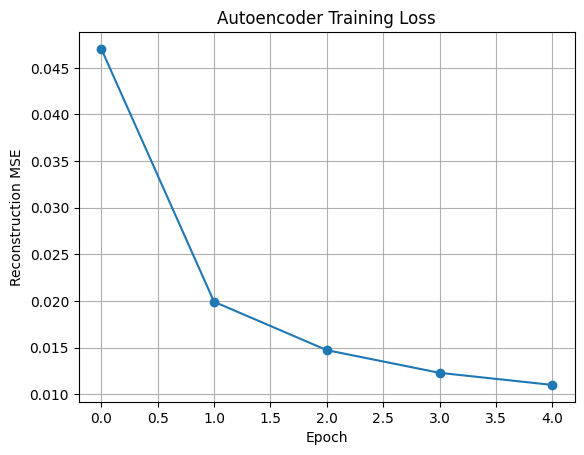

In [18]:
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder Training Loss")
plt.grid(True)
plt.show()

## Step 7: Compare original and reconstructed images

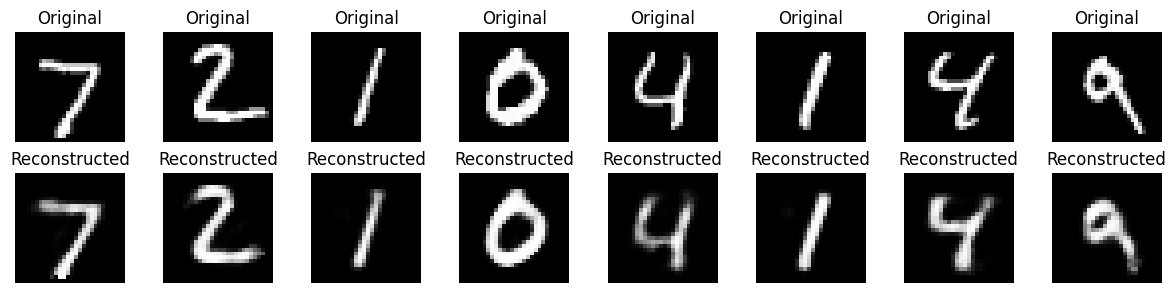

In [19]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    reconstructed, latent = model(images)
images = images.cpu()
reconstructed = reconstructed.cpu().view(-1, 1, 28, 28)
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstructed")
plt.tight_layout()
plt.show()

## Step 8: Inspect the latent representation

In [20]:
print("Input shape: ", images.shape)
print("Latent shape:", latent.shape)

Input shape:  torch.Size([128, 1, 28, 28])
Latent shape: torch.Size([128, 32])


## Extension: Denoising Autoencoder

A denoising autoencoder receives a corrupted input but is trained to reconstruct the original clean input. This extension demonstrates the idea without changing the basic encoder–decoder architecture.

In [21]:
def add_noise(images, noise_factor=0.3):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)

### Denoising Autoencoder Training

In [22]:
# Re-initialize the model and optimizer for denoising autoencoder training
# This ensures we start training from scratch for the denoising task
model_denoising = Autoencoder(latent_dim=32).to(device)
criterion_denoising = nn.MSELoss()
optimizer_denoising = optim.Adam(model_denoising.parameters(), lr=1e-3)

num_epochs_denoising = 5
dae_train_losses = []

print("Starting Denoising Autoencoder training...")
for epoch in range(num_epochs_denoising):
    model_denoising.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images)

        optimizer_denoising.zero_grad()
        reconstructed, latent = model_denoising(noisy_images)
        clean_flat = images.view(images.size(0), -1)
        loss = criterion_denoising(reconstructed, clean_flat)
        loss.backward()
        optimizer_denoising.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    dae_train_losses.append(epoch_loss)
    print(f"DAE Epoch [{epoch+1}/{num_epochs_denoising}], Loss: {epoch_loss:.4f}")

print("Denoising Autoencoder training complete!")

Starting Denoising Autoencoder training...
DAE Epoch [1/5], Loss: 0.0548
DAE Epoch [2/5], Loss: 0.0275
DAE Epoch [3/5], Loss: 0.0215
DAE Epoch [4/5], Loss: 0.0190
DAE Epoch [5/5], Loss: 0.0171
Denoising Autoencoder training complete!


### Plotting Denoising Autoencoder Training Loss

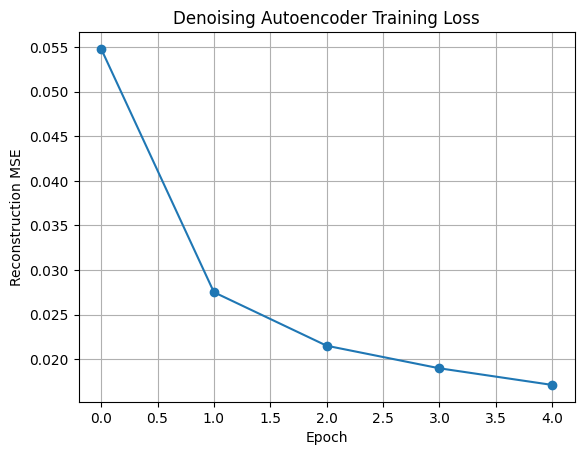

In [23]:
plt.plot(dae_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Denoising Autoencoder Training Loss")
plt.grid(True)
plt.show()

### Compare Noisy Input, Reconstructed Output, and Clean Target

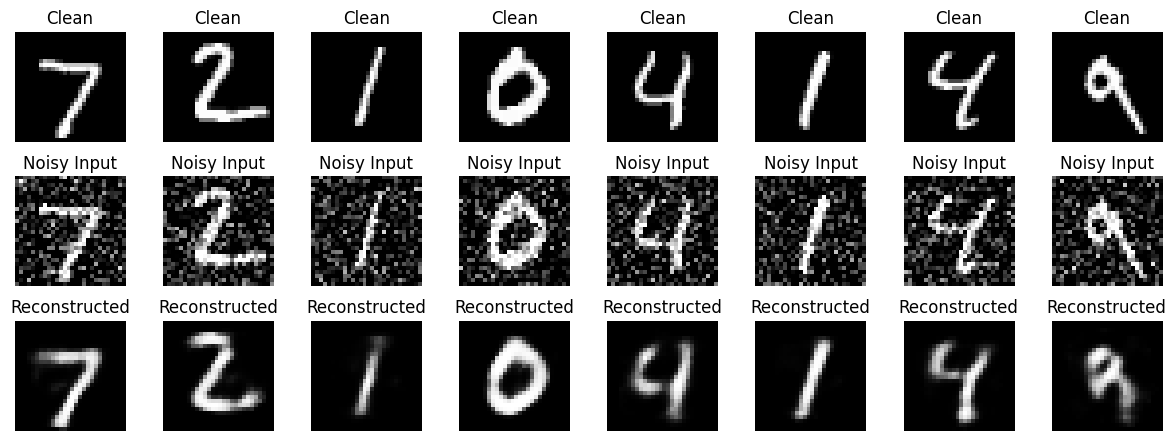

In [24]:
model_denoising.eval()
images, labels = next(iter(test_loader))
images = images.to(device)

noisy_images_display = add_noise(images, noise_factor=0.3)

with torch.no_grad():
    reconstructed_dae, _ = model_denoising(noisy_images_display)

images_cpu = images.cpu()
noisy_images_cpu = noisy_images_display.cpu()
reconstructed_dae_cpu = reconstructed_dae.cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(3, 8, figsize=(12, 4.5))
for i in range(8):
    # Original Clean Images
    axes[0, i].imshow(images_cpu[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Clean")

    # Noisy Input Images
    axes[1, i].imshow(noisy_images_cpu[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Noisy Input")

    # Reconstructed Images
    axes[2, i].imshow(reconstructed_dae_cpu[i].squeeze(), cmap="gray")
    axes[2, i].axis("off")
    axes[2, i].set_title("Reconstructed")

plt.tight_layout()
plt.show()

## Mini-Experiment: Effect of bottleneck size

In this mini-experiment, we will investigate how different latent dimensions (bottleneck sizes) affect the autoencoder's reconstruction quality. We will train autoencoders with varying `latent_dim` values and observe the changes in training loss and reconstructed images.

In [25]:
latent_dims = [2, 8, 32, 128]
experiment_losses = {}
num_epochs_experiment = 5

print("Starting Mini-Experiment: Effect of Bottleneck Size...")

for l_dim in latent_dims:
    print(f"\nTraining Autoencoder with latent_dim = {l_dim}")
    model_exp = Autoencoder(latent_dim=l_dim).to(device)
    criterion_exp = nn.MSELoss()
    optimizer_exp = optim.Adam(model_exp.parameters(), lr=1e-3)

    current_losses = []
    for epoch in range(num_epochs_experiment):
        model_exp.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            optimizer_exp.zero_grad()
            reconstructed, latent = model_exp(images)
            images_flat = images.view(images.size(0), -1)
            loss = criterion_exp(reconstructed, images_flat)
            loss.backward()
            optimizer_exp.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        current_losses.append(epoch_loss)
        print(f"  Epoch [{epoch+1}/{num_epochs_experiment}], Loss: {epoch_loss:.4f}")
    experiment_losses[l_dim] = current_losses

print("\nMini-Experiment complete!")

Starting Mini-Experiment: Effect of Bottleneck Size...

Training Autoencoder with latent_dim = 2
  Epoch [1/5], Loss: 0.0629
  Epoch [2/5], Loss: 0.0501
  Epoch [3/5], Loss: 0.0482
  Epoch [4/5], Loss: 0.0468
  Epoch [5/5], Loss: 0.0458

Training Autoencoder with latent_dim = 8
  Epoch [1/5], Loss: 0.0498
  Epoch [2/5], Loss: 0.0287
  Epoch [3/5], Loss: 0.0259
  Epoch [4/5], Loss: 0.0245
  Epoch [5/5], Loss: 0.0237

Training Autoencoder with latent_dim = 32
  Epoch [1/5], Loss: 0.0469
  Epoch [2/5], Loss: 0.0200
  Epoch [3/5], Loss: 0.0150
  Epoch [4/5], Loss: 0.0126
  Epoch [5/5], Loss: 0.0113

Training Autoencoder with latent_dim = 128
  Epoch [1/5], Loss: 0.0460
  Epoch [2/5], Loss: 0.0179
  Epoch [3/5], Loss: 0.0125
  Epoch [4/5], Loss: 0.0102
  Epoch [5/5], Loss: 0.0087

Mini-Experiment complete!


### Plotting Training Losses for Different Bottleneck Sizes

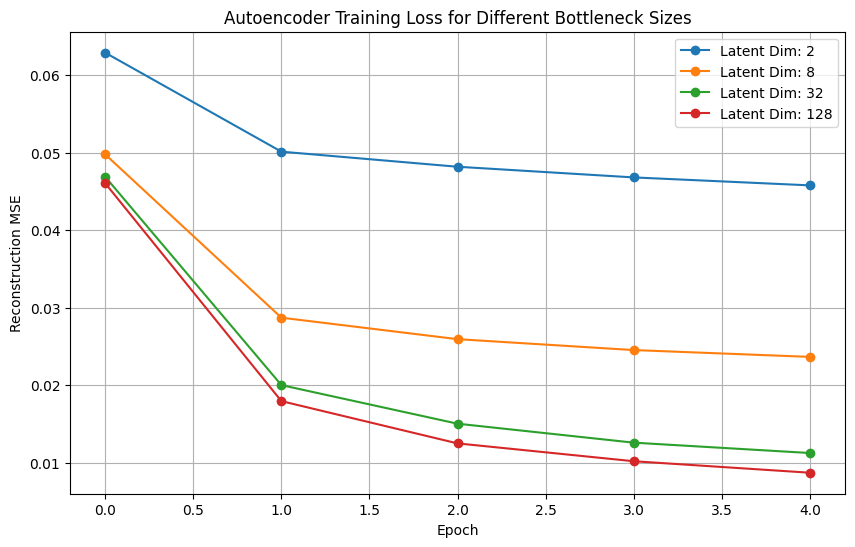

In [26]:
plt.figure(figsize=(10, 6))
for l_dim, losses in experiment_losses.items():
    plt.plot(losses, marker='o', label=f'Latent Dim: {l_dim}')

plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder Training Loss for Different Bottleneck Sizes")
plt.legend()
plt.grid(True)
plt.show()

### Visualizing Reconstructions for Selected Latent Dimensions

Let's visualize the reconstructions for a small (`latent_dim=2`), medium (`latent_dim=32`), and large (`latent_dim=128`) bottleneck size to see the qualitative differences.

Generating reconstructions for latent_dim = 2
Generating reconstructions for latent_dim = 32
Generating reconstructions for latent_dim = 128


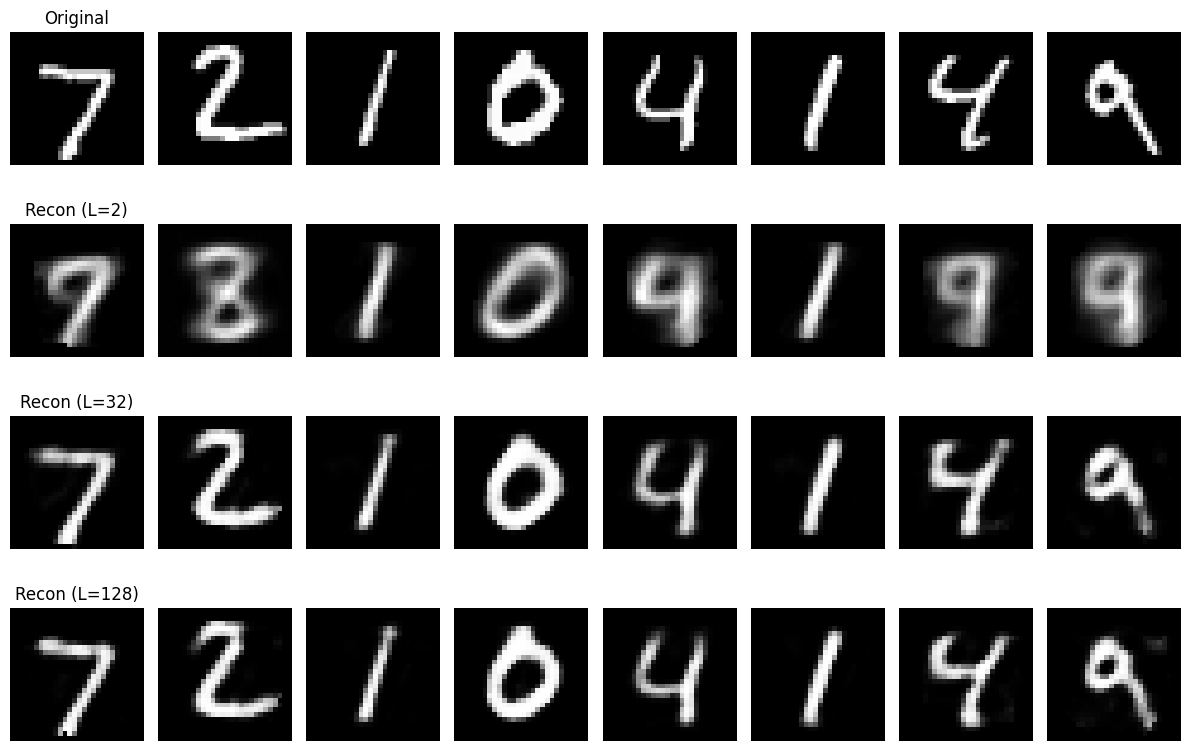

In [27]:
selected_latent_dims_for_viz = [2, 32, 128] # Small, medium, large

# Get a batch of test images
images, _ = next(iter(test_loader))
images = images.to(device)

fig, axes = plt.subplots(len(selected_latent_dims_for_viz) + 1, 8, figsize=(12, 2 * (len(selected_latent_dims_for_viz) + 1)))

# Plot original images
for i in range(8):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Original")

# Train and visualize for each selected latent dimension
for idx, l_dim in enumerate(selected_latent_dims_for_viz):
    print(f"Generating reconstructions for latent_dim = {l_dim}")
    model_viz = Autoencoder(latent_dim=l_dim).to(device)
    criterion_viz = nn.MSELoss()
    optimizer_viz = optim.Adam(model_viz.parameters(), lr=1e-3)

    # Train for a few epochs (or load pre-trained if available, but for simplicity, retrain)
    for epoch in range(num_epochs_experiment):
        model_viz.train()
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer_viz.zero_grad()
            reconstructed_viz, _ = model_viz(imgs)
            imgs_flat = imgs.view(imgs.size(0), -1)
            loss_viz = criterion_viz(reconstructed_viz, imgs_flat)
            loss_viz.backward()
            optimizer_viz.step()

    model_viz.eval()
    with torch.no_grad():
        reconstructed_output, _ = model_viz(images)

    reconstructed_output = reconstructed_output.cpu().view(-1, 1, 28, 28)

    for i in range(8):
        axes[idx + 1, i].imshow(reconstructed_output[i].squeeze(), cmap='gray')
        axes[idx + 1, i].axis('off')
        if i == 0:
            axes[idx + 1, i].set_title(f"Recon (L={l_dim})")

plt.tight_layout()
plt.show()

## Extension: Variational Autoencoder (VAE)

A Variational Autoencoder (VAE) is a generative model that learns a probabilistic mapping from the input data to a latent space, allowing for the generation of new data samples. Unlike standard autoencoders, VAEs learn the parameters of a probability distribution (mean and variance) for each dimension of the latent space, rather than directly learning the latent vector itself.

### Define the Variational Autoencoder (VAE)

In [28]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, logvar

# Initialize VAE model
vae_latent_dim = 20 # Common latent dimension for VAEs
model_vae = VAE(latent_dim=vae_latent_dim).to(device)
print(model_vae)

VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=400, bias=True)
    (2): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


### Define VAE Loss Function

Unlike the standard Autoencoder which only uses a reconstruction loss (MSE), the VAE loss function combines two terms:
1.  **Reconstruction Loss:** Measures how well the VAE can reconstruct the input (e.g., Binary Cross-Entropy for pixel-wise probabilities, or MSE).
2.  **KL Divergence Loss:** Measures the divergence between the learned latent distribution and a standard Gaussian prior. This regularizes the latent space and encourages it to be well-structured and continuous.

In [29]:
def vae_loss_function(x_reconstructed, x, mu, logvar):
    # Reconstruction loss (Binary Cross-Entropy for pixel values between 0 and 1)
    BCE = nn.functional.binary_cross_entropy(x_reconstructed, x.view(-1, 28 * 28), reduction='sum')

    # KL Divergence loss
    # KL = 0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    KL_D = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KL_D

In [32]:
# Optimizer for VAE
optimizer_vae = optim.Adam(model_vae.parameters(), lr=1e-3)

num_epochs_vae = 10 # VAEs often benefit from slightly more epochs
vae_train_losses = []

print("Starting VAE training...")
for epoch in range(num_epochs_vae):
    model_vae.train()
    running_loss = 0.0
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)
        optimizer_vae.zero_grad()

        x_reconstructed, mu, logvar = model_vae(images)
        loss = vae_loss_function(x_reconstructed, images, mu, logvar)

        loss.backward()
        optimizer_vae.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_data) # Normalize by total number of training samples
    vae_train_losses.append(epoch_loss)
    print(f"VAE Epoch [{epoch+1}/{num_epochs_vae}], Loss: {epoch_loss:.4f}")

print("VAE training complete!")

Starting VAE training...
VAE Epoch [1/10], Loss: 110.3246
VAE Epoch [2/10], Loss: 108.8992
VAE Epoch [3/10], Loss: 108.0243
VAE Epoch [4/10], Loss: 107.3202
VAE Epoch [5/10], Loss: 106.7750
VAE Epoch [6/10], Loss: 106.2847
VAE Epoch [7/10], Loss: 105.9058
VAE Epoch [8/10], Loss: 105.6376
VAE Epoch [9/10], Loss: 105.3279
VAE Epoch [10/10], Loss: 105.0273
VAE training complete!


### Plot VAE Training Loss

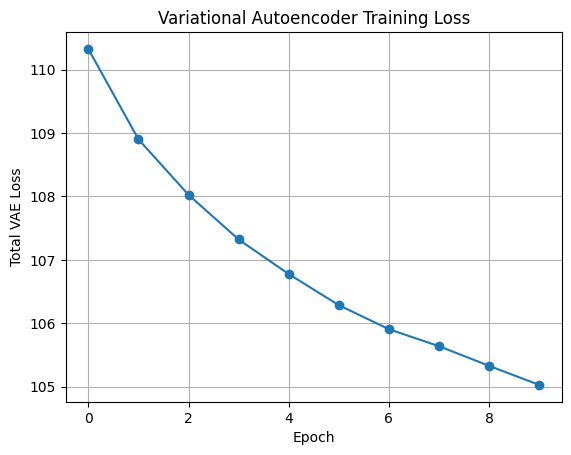

In [33]:
plt.plot(vae_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Total VAE Loss")
plt.title("Variational Autoencoder Training Loss")
plt.grid(True)
plt.show()

### Generate New Digits from VAE Latent Space

One of the main advantages of VAEs is their ability to generate new, realistic samples by sampling from the latent space. Since the VAE learns a continuous and structured latent distribution, we can sample random points from this distribution and feed them through the decoder to generate novel images.

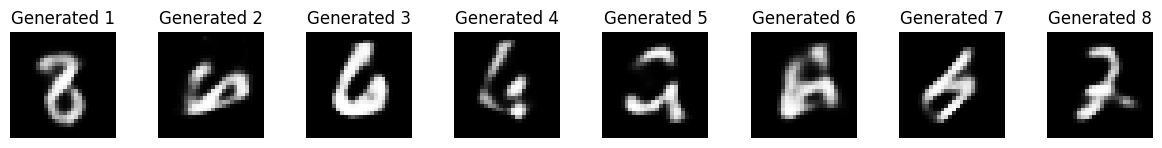

In [34]:
model_vae.eval()

# Generate 8 random latent vectors from a standard normal distribution
# (since our KL divergence term encourages the latent space to resemble a standard normal)
num_samples_to_generate = 8
sample = torch.randn(num_samples_to_generate, vae_latent_dim).to(device)

with torch.no_grad():
    generated_images = model_vae.decode(sample).cpu()

fig, axes = plt.subplots(1, num_samples_to_generate, figsize=(12, 1.5))
for i in range(num_samples_to_generate):
    axes[i].imshow(generated_images[i].view(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Generated {i+1}')

plt.tight_layout()
plt.show()

### Compare Original and VAE Reconstructed Images

Let's also visualize how well the VAE reconstructs original images, similar to the standard Autoencoder.

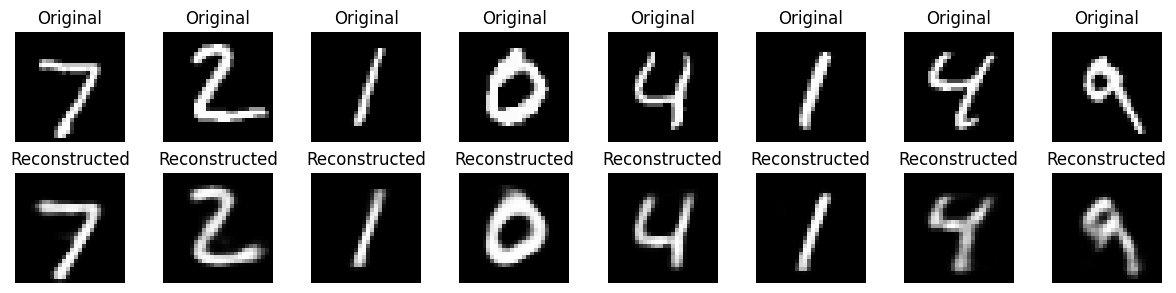

In [35]:
model_vae.eval()
images_test, _ = next(iter(test_loader))
images_test = images_test.to(device)

with torch.no_grad():
    reconstructed_vae, _, _ = model_vae(images_test)

images_test_cpu = images_test.cpu()
reconstructed_vae_cpu = reconstructed_vae.cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    # Original Images
    axes[0, i].imshow(images_test_cpu[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    # Reconstructed Images
    axes[1, i].imshow(reconstructed_vae_cpu[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstructed")

plt.tight_layout()
plt.show()

### Visualize Latent Space Clustering

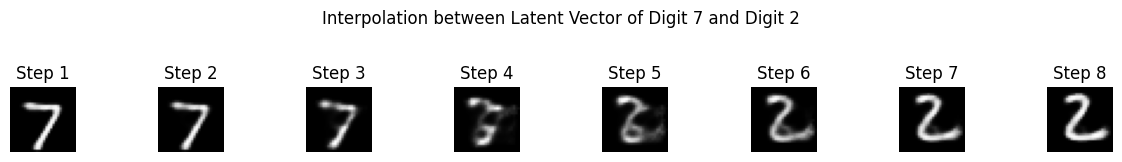

In [38]:
model_vae.eval()

# Get a batch of test images and their latent representations
images_interp, labels_interp = next(iter(test_loader))
images_interp = images_interp.to(device)

with torch.no_grad():
    _, mu_interp, logvar_interp = model_vae(images_interp)

# Select two latent vectors for interpolation (e.g., first two samples in the batch)
# Or, more deliberately, find two different digits

# Let's try to find two different digits if available in the first batch
# For simplicity, we'll just pick the first two in the batch, assuming they are likely different enough.
# A more robust approach would iterate through the batch to find specific digit pairs.

# If we want to be very specific about digits, we can uncomment and use code like this:
# digit_0_idx = (labels_interp == 0).nonzero(as_tuple=True)[0]
# digit_1_idx = (labels_interp == 1).nonzero(as_tuple=True)[0]
# if len(digit_0_idx) > 0 and len(digit_1_idx) > 0:
#     z1 = mu_interp[digit_0_idx[0]]
#     z2 = mu_interp[digit_1_idx[0]]
# else:
#     print("Could not find specific digits 0 and 1 in the batch, using first two samples.")
#     z1 = mu_interp[0]
#     z2 = mu_interp[1]

z1 = mu_interp[0]
z2 = mu_interp[1]

# Number of interpolation steps
num_interpolation_steps = 8

# Create interpolated latent vectors
interpolated_latents = []
for i in range(num_interpolation_steps):
    alpha = i / (num_interpolation_steps - 1)
    interpolated_z = (1 - alpha) * z1 + alpha * z2
    interpolated_latents.append(interpolated_z)

interpolated_latents = torch.stack(interpolated_latents).to(device)

# Decode the interpolated latent vectors
with torch.no_grad():
    interpolated_images = model_vae.decode(interpolated_latents).cpu()

# Plot the interpolated images
fig, axes = plt.subplots(1, num_interpolation_steps, figsize=(12, 1.5))
for i in range(num_interpolation_steps):
    axes[i].imshow(interpolated_images[i].view(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Step {i+1}')

plt.suptitle(f'Interpolation between Latent Vector of Digit {labels_interp[0].item()} and Digit {labels_interp[1].item()}', y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

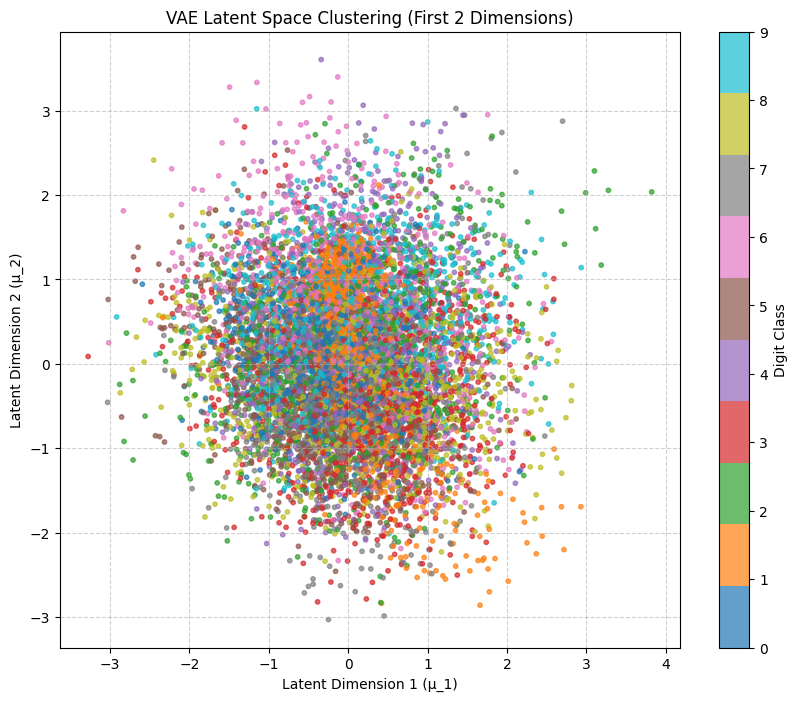

In [36]:
model_vae.eval()

all_latent_mus = []
all_labels = []

# Collect latent means and labels from the test set
for images, labels in test_loader:
    images = images.to(device)
    with torch.no_grad():
        _, mu, _ = model_vae(images)
    all_latent_mus.append(mu.cpu())
    all_labels.append(labels.cpu())

all_latent_mus = torch.cat(all_latent_mus, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

# Plotting the first two dimensions of the latent space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_latent_mus[:, 0], all_latent_mus[:, 1],
                      c=all_labels, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.xlabel('Latent Dimension 1 (μ_1)')
plt.ylabel('Latent Dimension 2 (μ_2)')
plt.title('VAE Latent Space Clustering (First 2 Dimensions)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Lab Tasks


### 1. For basic Autoencoder:

*   **Final Reconstruction Loss on Training Set:** The final reconstruction loss (MSE) on the training set after 5 epochs was **0.0110**.

*   **Chosen Latent Dimension:** The latent dimension (`latent_dim`) chosen for the basic autoencoder was **32**.

*   **Visual Description of Reconstruction Quality:** The network reconstructs images quite well. The original digits are clearly recognizable in their reconstructed counterparts, demonstrating that the autoencoder has learned a meaningful compressed representation.

### 2. For Denoising Autoencoder:

*   **Final Reconstruction Loss on Training Set:** The final reconstruction loss (MSE) on the training set for the Denoising Autoencoder after 5 epochs was **0.0171**.

*   **Visual Description of Reconstruction from Noisy Inputs:** The Denoising Autoencoder performs impressively in reconstructing clean images from noisy inputs. Despite significant corruption of the input images, the model is largely able to remove the noise and produce clear, recognizable digits. This highlights its capability to learn robust features and effectively denoise data.

### 3. For Mini-Experiment (Effect of Bottleneck Size):

*   **Observations on Reconstruction Loss:** As the latent dimension (bottleneck size) increases, the reconstruction loss (MSE) consistently decreases. This is expected, as a larger bottleneck allows the autoencoder to retain more information about the input, leading to more accurate reconstructions. The smallest latent dimension (2) had the highest loss, while the largest (128) had the lowest.

*   **Observations on Visual Quality of Reconstructed Images:** The visual quality of reconstructed images directly correlates with the latent dimension. For `latent_dim=2`, reconstructions were very blurry and abstract, losing most discernible features. With `latent_dim=32`, images became significantly clearer and highly recognizable. At `latent_dim=128`, the reconstructions were nearly perfect, very closely resembling the original images. This demonstrates the trade-off between compression and fidelity.

### 4. For Variational Autoencoder (VAE):

*   **Final VAE Loss on Training Set:** The final total VAE loss on the training set after 10 epochs was **105.0273**.

*   **Visual Description of Generated New Samples:** The VAE successfully generates new, digit-like samples by decoding random vectors from the latent space. These generated images, while sometimes blurry or not perfectly formed, generally resemble MNIST digits, demonstrating the VAE's generative capabilities.

*   **Visual Description of Reconstruction Quality:** The VAE's reconstruction quality for original images is good, similar to a standard autoencoder. The reconstructed digits are clear and closely match their original counterparts, indicating the model's ability to learn effective encoding and decoding mappings.

*   **Visual Description of Latent Space Clustering:** When plotting the first two dimensions of the VAE's latent space, we observe some degree of clustering for different digit classes. Although there is overlap, which is common in higher-dimensional latent spaces projected to 2D, distinct regions can be seen where points corresponding to specific digits (e.g., 0s, 1s, 7s) tend to concentrate. This suggests that the VAE has learned a structured latent representation where similar digits are mapped to proximate locations.

### 5. Task: Implement the generation of new handwritten digits using VAE by decoding interpolated latent vectors.



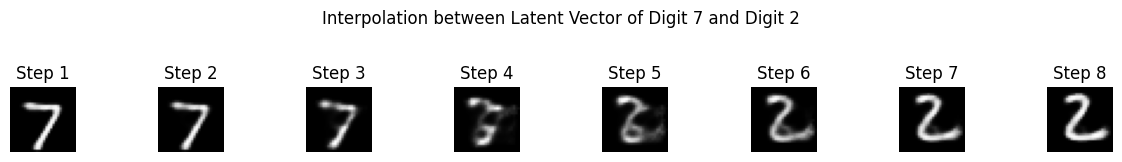

In [37]:
model_vae.eval()

# Get a batch of test images and their latent representations
images_interp, labels_interp = next(iter(test_loader))
images_interp = images_interp.to(device)

with torch.no_grad():
    _, mu_interp, logvar_interp = model_vae(images_interp)

# Select two latent vectors for interpolation (e.g., first two samples in the batch)
# Or, more deliberately, find two different digits

# Let's try to find two different digits if available in the first batch
# For simplicity, we'll just pick the first two in the batch, assuming they are likely different enough.
# A more robust approach would iterate through the batch to find specific digit pairs.

# If we want to be very specific about digits, we can uncomment and use code like this:
# digit_0_idx = (labels_interp == 0).nonzero(as_tuple=True)[0]
# digit_1_idx = (labels_interp == 1).nonzero(as_tuple=True)[0]
# if len(digit_0_idx) > 0 and len(digit_1_idx) > 0:
#     z1 = mu_interp[digit_0_idx[0]]
#     z2 = mu_interp[digit_1_idx[0]]
# else:
#     print("Could not find specific digits 0 and 1 in the batch, using first two samples.")
#     z1 = mu_interp[0]
#     z2 = mu_interp[1]

z1 = mu_interp[0]
z2 = mu_interp[1]

# Number of interpolation steps
num_interpolation_steps = 8

# Create interpolated latent vectors
interpolated_latents = []
for i in range(num_interpolation_steps):
    alpha = i / (num_interpolation_steps - 1)
    interpolated_z = (1 - alpha) * z1 + alpha * z2
    interpolated_latents.append(interpolated_z)

interpolated_latents = torch.stack(interpolated_latents).to(device)

# Decode the interpolated latent vectors
with torch.no_grad():
    interpolated_images = model_vae.decode(interpolated_latents).cpu()

# Plot the interpolated images
fig, axes = plt.subplots(1, num_interpolation_steps, figsize=(12, 1.5))
for i in range(num_interpolation_steps):
    axes[i].imshow(interpolated_images[i].view(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Step {i+1}')

plt.suptitle(f'Interpolation between Latent Vector of Digit {labels_interp[0].item()} and Digit {labels_interp[1].item()}', y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 6. Viva Questions


*   **Explain the difference between a standard Autoencoder and a Variational Autoencoder.**
    *   **Standard Autoencoder:** Aims to learn a compressed representation (latent vector) of the input data and reconstruct the input from this representation. It learns a deterministic mapping from input to latent space and latent space to output. The latent space is not necessarily continuous or easily sampled for generation.
    *   **Variational Autoencoder (VAE):** Learns a probabilistic mapping from the input data to a latent space. Instead of a single latent vector, the encoder outputs parameters (mean and variance) of a probability distribution (typically Gaussian) in the latent space. A sample is then drawn from this distribution using the reparameterization trick, which is then fed to the decoder. The VAE loss function includes both a reconstruction term and a KL divergence term that forces the learned latent distributions to be close to a prior distribution (e.g., a standard normal distribution). This ensures a continuous and structured latent space, making VAEs excellent for generating new, similar data samples.

*   **Why is the reparameterization trick necessary in VAEs?**
    *   The reparameterization trick is necessary for backpropagation. In VAEs, we want to optimize the parameters of the encoder that produce the mean (`mu`) and log variance (`logvar`) of the latent distribution. However, sampling `z` from this distribution (`z = mu + std * epsilon`) introduces a non-differentiable step. The reparameterization trick separates the random sampling part (drawing `epsilon` from a standard normal distribution) from the deterministic transformation that depends on `mu` and `logvar`. This allows the gradients to flow back through `mu` and `logvar`, enabling the training of the encoder via gradient descent.

*   **How does the bottleneck size affect the performance of an autoencoder?**
    *   The bottleneck size (latent dimension) directly impacts the autoencoder's capacity to compress and reconstruct data:
        *   **Too Small:** A very small bottleneck size forces extreme compression. The autoencoder will struggle to capture sufficient information to reconstruct the input accurately, leading to high reconstruction loss and blurry/distorted outputs. It acts as a severe information bottleneck.
        *   **Too Large:** A very large bottleneck size allows the autoencoder to potentially learn an identity function, simply memorizing the input without learning a meaningful compressed representation. While reconstruction loss might be very low, the latent representation might not be useful for tasks like dimensionality reduction or feature extraction, and the model may not generalize well.
        *   **Optimal:** An optimal bottleneck size is a trade-off. It's small enough to force the model to learn meaningful, compact features (compression) but large enough to retain essential information for accurate reconstruction. The specific optimal size depends on the complexity of the data.

*   **Describe a real-world application of autoencoders or VAEs (other than MNIST generation).**
    *   **Anomaly Detection:** Autoencoders are widely used for anomaly detection. By training an autoencoder on a dataset of 'normal' data, it learns to reconstruct these normal patterns effectively. When presented with anomalous data, the autoencoder will typically produce a high reconstruction error because the anomaly deviates significantly from the patterns it was trained on. This high error can be used as an indicator of an anomaly. For example, in industrial quality control, an autoencoder can learn patterns of normal machinery operation or product images; deviations from these patterns, indicated by high reconstruction error, signal defects or malfunctions. In network security, autoencoders can detect unusual network traffic patterns indicating intrusions.